In [272]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt

# Read input

In [273]:
FINDER = 'minimap2'
# FINDER = 'repeat-scout'
# FINDER = 'phraider'
# FINDER = 'total-repeats'
# FINDER = 'repeat-modeler'
# FINDER = 'grf'
# FINDER = 'reprise'

In [274]:
MUTATION_TYPE = 'SNP' # choice
# MUTATION_TYPE = 'SNP_INS' # choice
# MUTATION_TYPE = 'SNP_DEL' # choice
# MUTATION_TYPE = 'SNP_INDEL' # choice

x_label_part = 'однонуклеотидных замен'
if MUTATION_TYPE == 'SNP_INS':
    x_label_part = 'однонуклеотидных замен и инсерций'
elif MUTATION_TYPE == 'SNP_DEL':
    x_label_part = 'однонуклеотидных замен и делеций'
elif MUTATION_TYPE == 'SNP_INDEL':
    x_label_part = 'однонуклеотидных замен и инделов'
# end if

In [275]:
N_DESIRED_REPEAT_COPIES = 3

In [276]:
workdir_path = '/mnt/data/Max/repos/reverlor/cmp_repeat_finders/test_repeat_detection/workdirs_{}copies/workdir_{}_{}'.format(
    N_DESIRED_REPEAT_COPIES,
    FINDER,
    MUTATION_TYPE
)
raw_infpath = '{}/repeat_detection_table_raw.tsv'.format(
    workdir_path
)
detect_infpath = '{}/repeat_detection_table.tsv'.format(
    workdir_path
)

In [277]:
df_raw = pl.read_csv(raw_infpath, separator='\t')
df_raw = df_raw.with_columns(
    (
        'MR_l' + pl.col('repeat_len').cast(pl.String) \
        + '_' \
        + 'r' + pl.col('replicate_idx').cast(pl.String) \
        + '_' \
        + 't' + pl.col('rate').cast(pl.String) \
    ).alias('repeat_id')
)
if FINDER == 'phraider':
    df_raw = df_raw.filter(
        ~(
            (pl.col('value_type') == 'true') & (pl.col('strand') == '-')
        )
    )
# end if
print(df_raw.shape)
df_raw.head()

(2454, 9)


chr,repeat_len,replicate_idx,rate,value_type,start_coord,end_coord,strand,repeat_id
str,i64,i64,f64,str,i64,i64,str,str
"""replicon_1""",10000,0,0.0,"""true""",241716,251716,"""-""","""MR_l10000_r0_t0.0"""
"""replicon_1""",10000,0,0.0,"""true""",492195,502195,"""-""","""MR_l10000_r0_t0.0"""
"""replicon_2""",10000,0,0.0,"""true""",2104,12104,"""-""","""MR_l10000_r0_t0.0"""
"""replicon_1""",10000,0,0.0,"""pred""",241716,251718,""".""","""MR_l10000_r0_t0.0"""
"""replicon_1""",10000,0,0.0,"""pred""",492193,502198,""".""","""MR_l10000_r0_t0.0"""


In [278]:
true_df = df_raw.filter(
    pl.col('value_type') == 'true'
)

In [279]:
repeat_detect_df = pl.read_csv(
    detect_infpath,
    separator='\t',
    null_values=['NA', '', 'na']
)
print(repeat_detect_df.shape)
repeat_detect_df.head()

(1261, 10)


chr,repeat_id,true_start_coord,true_end_coord,pred_start_coord,pred_end_coord,repeat_detected,repeat_len,replicate_idx,rate
str,str,i64,i64,i64,i64,i64,i64,i64,f64
"""replicon_1""","""MR_l3000_r9_t0.01""",106452,109452,106452,109452,1,3000,9,0.01
"""replicon_1""","""MR_l127_r2_t0.03""",496575,496829,496693,496830,1,127,2,0.03
"""replicon_1""","""MR_l10000_r1_t0.01""",526498,536498,526497,536498,1,10000,1,0.01
"""replicon_1""","""MR_l10000_r6_t0.0""",20677,30677,20677,30678,1,10000,6,0.0
"""replicon_1""","""MR_l200_r9_t0.03""",206586,206786,206586,206787,1,200,9,0.03


# Inspection

In [280]:
repeat_detect_df.filter(
    (pl.col('rate') == 0.00) & (pl.col('repeat_len') == 10000) & (pl.col('repeat_detected') != 1)
).sort(by='replicate_idx')

chr,repeat_id,true_start_coord,true_end_coord,pred_start_coord,pred_end_coord,repeat_detected,repeat_len,replicate_idx,rate
str,str,i64,i64,i64,i64,i64,i64,i64,f64


In [281]:
repeat_detect_df.filter(
    (pl.col('repeat_len') == 10000) & (pl.col('repeat_detected') != 1)
).sort(by='replicate_idx')

chr,repeat_id,true_start_coord,true_end_coord,pred_start_coord,pred_end_coord,repeat_detected,repeat_len,replicate_idx,rate
str,str,i64,i64,i64,i64,i64,i64,i64,f64


In [282]:
repeat_detect_df.filter(
    (pl.col('rate') == 0.00) & (pl.col('repeat_len') == 500) & (pl.col('replicate_idx') == 1)
).sort(by='replicate_idx')

chr,repeat_id,true_start_coord,true_end_coord,pred_start_coord,pred_end_coord,repeat_detected,repeat_len,replicate_idx,rate
str,str,i64,i64,i64,i64,i64,i64,i64,f64
"""replicon_1""","""MR_l500_r1_t0.0""",271432,271932,271432,271933,1,500,1,0.0
"""replicon_1""","""MR_l500_r1_t0.0""",518906,519906,519405,519907,1,500,1,0.0
"""replicon_2""","""MR_l500_r1_t0.0""",722,1222,721,1222,1,500,1,0.0


In [283]:
df_raw.filter(
    (pl.col('rate') == 0.00) & (pl.col('repeat_len') == 127) & (pl.col('replicate_idx') == 3)
).sort(by=['replicate_idx', 'value_type', 'start_coord'])

chr,repeat_len,replicate_idx,rate,value_type,start_coord,end_coord,strand,repeat_id
str,i64,i64,f64,str,i64,i64,str,str
"""replicon_2""",127,3,0.0,"""pred""",1783,1911,""".""","""MR_l127_r3_t0.0"""
"""replicon_1""",127,3,0.0,"""pred""",268103,268231,""".""","""MR_l127_r3_t0.0"""
"""replicon_1""",127,3,0.0,"""pred""",518137,518266,""".""","""MR_l127_r3_t0.0"""
"""replicon_2""",127,3,0.0,"""true""",1784,1911,"""+""","""MR_l127_r3_t0.0"""
"""replicon_1""",127,3,0.0,"""true""",268103,268230,"""+""","""MR_l127_r3_t0.0"""
"""replicon_1""",127,3,0.0,"""true""",518138,518265,"""+""","""MR_l127_r3_t0.0"""


In [284]:
# TODO: remove?
# N_repeats = true_df.filter(
#     pl.col('rate') == 0.0
# ).shape[0]
# print('N_repeats = {}'.format(N_repeats))

# per_rate_summary_df = repeat_detect_df.group_by('rate').agg(
#     pl.col('repeat_detected').sum().alias('repeat_detected_count')
# ).sort(by=['rate'])

# per_rate_summary_df = per_rate_summary_df.with_columns(
#     (pl.col('repeat_detected_count') / N_repeats * 100.0).alias('repeat_detected_percent')
# )

# per_rate_summary_df.head(10)

# Helper functions

In [285]:
def get_per_rate_df(repeat_detect_df, true_df, repeat_len=200):
    N_repeats = true_df.filter(
        (pl.col('repeat_len') == repeat_len) \
        & (pl.col('rate') == 0.0)
    ).height
    print('N_repeats = {}'.format(N_repeats))

    # TODO: remove
    # result_df = repeat_detect_df.filter(
    #     pl.col('repeat_len') == repeat_len
    # ).unique(
    #     subset=['chr', 'repeat_id']
    # ).group_by('rate').agg(
    #     pl.col('repeat_detected').sum().alias('repeat_detected_count')
    # ).sort(by=['rate'])

    result_df = repeat_detect_df.filter(
        pl.col('repeat_len') == repeat_len
    ).group_by('rate').agg(
        pl.col('repeat_detected').sum().alias('repeat_detected_count')
    ).sort(by=['rate'])
    
    result_df = result_df.with_columns(
        (pl.col('repeat_detected_count') / N_repeats * 100.0).alias('repeat_detected_percent'),
        pl.lit(repeat_len).alias('repeat_len')
    ).with_columns(
        pl.min_horizontal(pl.col('repeat_detected_count'), N_repeats).alias('repeat_detected_count'),
        pl.min_horizontal(pl.col('repeat_detected_percent'), 100.0).alias('repeat_detected_percent'),
    )

    return result_df
# end def

def get_per_rate_coord_diff_df(repeat_detect_df, true_df, repeat_len=200):

    tmp_df = repeat_detect_df.filter(
        (pl.col('repeat_len') == repeat_len) \
      & (pl.col('repeat_detected') == 1)
    ).with_columns(
        (pl.col('pred_start_coord') - pl.col('true_start_coord')).abs().alias('start_coord_diff'),
        (pl.col('pred_end_coord') - pl.col('true_end_coord')).abs().alias('end_coord_diff')
    ).with_columns(
        (pl.col('repeat_id') + '_' + pl.col('chr')).alias('repeat_id')
    )

    min_start_coord_diff_df = tmp_df.group_by('repeat_id') \
        .agg(pl.col('start_coord_diff').min())
    min_end_coord_diff_df = tmp_df.group_by('repeat_id') \
        .agg(pl.col('end_coord_diff').min())

    result_df = tmp_df.select(
        pl.col('chr', 'repeat_id', 'replicate_idx', 'rate')
    ).join(
        min_start_coord_diff_df,
        on='repeat_id',
        how='left'
    ).join(
        min_end_coord_diff_df,
        on='repeat_id',
        how='left'
    ).with_columns(
        (pl.col('start_coord_diff') + pl.col('end_coord_diff')).alias('coord_diff_sum'),
        pl.lit(repeat_len).alias('repeat_len')
    )

    return result_df
# end def

# Make total detection plot

In [286]:
per_rate_len127_summary_df = get_per_rate_df(
    repeat_detect_df,
    true_df,
    repeat_len=127
)
per_rate_len200_summary_df = get_per_rate_df(
    repeat_detect_df,
    true_df,
    repeat_len=200
)
per_rate_len500_summary_df = get_per_rate_df(
    repeat_detect_df,
    true_df,
    repeat_len=500
)
per_rate_len1k_summary_df = get_per_rate_df(
    repeat_detect_df,
    true_df,
    repeat_len=1000
)
per_rate_len10k_summary_df = get_per_rate_df(
    repeat_detect_df,
    true_df,
    repeat_len=10000
)
all_summary_df = pl.concat([
    per_rate_len127_summary_df,
    per_rate_len200_summary_df,
    per_rate_len500_summary_df,
    per_rate_len1k_summary_df,
    per_rate_len10k_summary_df,
])
all_summary_df = all_summary_df.with_columns(
    pl.col('repeat_len').cast(pl.String)
)
all_summary_df.head()

N_repeats = 30
N_repeats = 30
N_repeats = 30
N_repeats = 30
N_repeats = 30


rate,repeat_detected_count,repeat_detected_percent,repeat_len
f64,i64,f64,str
0.0,30,100.0,"""127"""
0.01,29,96.666667,"""127"""
0.02,28,93.333333,"""127"""
0.03,22,73.333333,"""127"""
0.04,13,43.333333,"""127"""


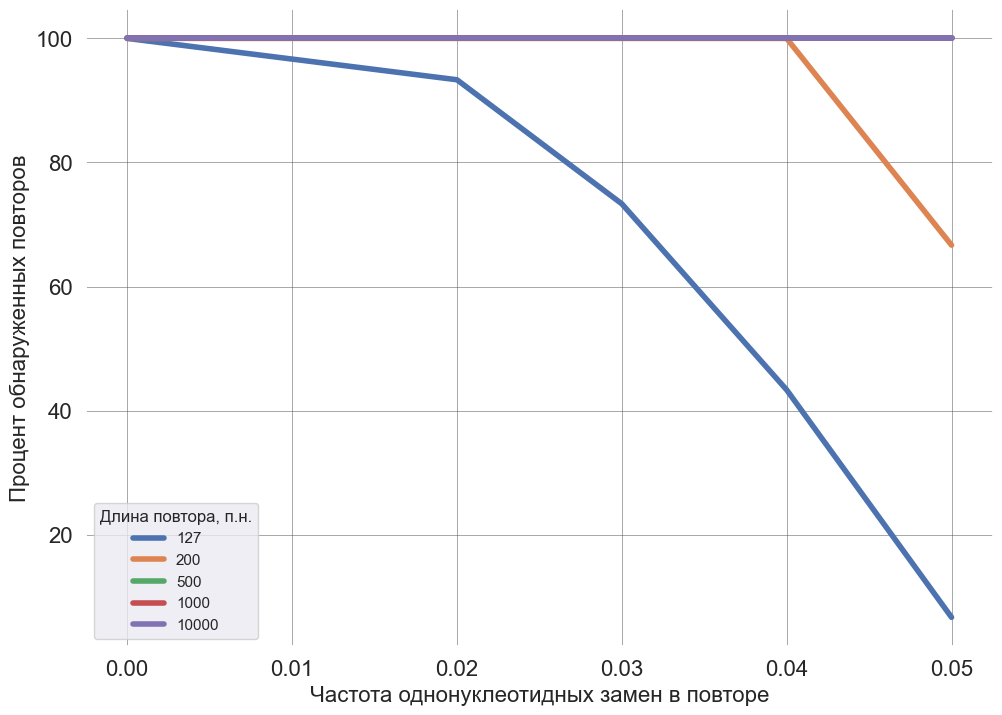

In [287]:
sns.set_theme(rc={'figure.figsize':(11.7,8.27)})

ax = sns.lineplot(
    all_summary_df,
    x='rate',
    y='repeat_detected_percent',
    hue='repeat_len',
    linewidth=4.0
)

ax.set_xlabel(f'Частота {x_label_part} в повторе', fontsize=16)
ax.set_ylabel('Процент обнаруженных повторов', fontsize=16)

plt.legend(title='Длина повтора, п.н.')

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

ax.grid(True, color='#505050', linestyle='-', linewidth=0.5, alpha=0.7)
ax.set_facecolor('#ffffff')

plt.show(ax)

# Make total coord diff plot

In [288]:
per_rate_len127_coord_diff_df = get_per_rate_coord_diff_df(
    repeat_detect_df,
    true_df,
    repeat_len=127
)
per_rate_len200_coord_diff_df = get_per_rate_coord_diff_df(
    repeat_detect_df,
    true_df,
    repeat_len=200
)
per_rate_len500_coord_diff_df = get_per_rate_coord_diff_df(
    repeat_detect_df,
    true_df,
    repeat_len=500
)
per_rate_len1k_coord_diff_df = get_per_rate_coord_diff_df(
    repeat_detect_df,
    true_df,
    repeat_len=1000
)
per_rate_len10k_coord_diff_df = get_per_rate_coord_diff_df(
    repeat_detect_df,
    true_df,
    repeat_len=10000
)

all_coord_df = pl.concat([
    per_rate_len127_coord_diff_df,
    per_rate_len200_coord_diff_df,
    per_rate_len500_coord_diff_df,
    per_rate_len1k_coord_diff_df,
    per_rate_len10k_coord_diff_df,
])
all_coord_df = all_coord_df.with_columns(
    pl.col('repeat_len').cast(pl.String)
)
all_coord_df.head()

chr,repeat_id,replicate_idx,rate,start_coord_diff,end_coord_diff,coord_diff_sum,repeat_len
str,str,i64,f64,i64,i64,i64,str
"""replicon_1""","""MR_l127_r2_t0.03_replicon_1""",2,0.03,8,1,9,"""127"""
"""replicon_1""","""MR_l127_r1_t0.01_replicon_1""",1,0.01,1,0,1,"""127"""
"""replicon_1""","""MR_l127_r5_t0.01_replicon_1""",5,0.01,0,0,0,"""127"""
"""replicon_2""","""MR_l127_r6_t0.03_replicon_2""",6,0.03,4,0,4,"""127"""
"""replicon_1""","""MR_l127_r5_t0.03_replicon_1""",5,0.03,0,4,4,"""127"""


In [289]:
# TODO: remove
# all_coord_mean_df = all_coord_df.group_by(['rate', 'repeat_len']) \
#     .agg(pl.col('coord_diff_sum').mean().alias('mean_coord_diff_sum'))

# sns.set_theme(rc={'figure.figsize':(11.7,8.27)})

# ax = sns.lineplot(
#     all_coord_mean_df,
#     x='rate',
#     y='mean_coord_diff_sum',
#     hue='repeat_len',
#     linewidth=4.0
# )

# ax.set_xlabel(f'Частота {x_label_part} в повторе', fontsize=16)
# ax.set_ylabel('Средняя сумма ошибки определения координат', fontsize=16)

# plt.legend(title='Длина повтора, п.н.')

# plt.xticks(fontsize=16)
# plt.yticks(fontsize=16)

# ax.grid(True, color='#505050', linestyle='-', linewidth=0.5, alpha=0.7)
# ax.set_facecolor('#ffffff')

# plt.show(ax)

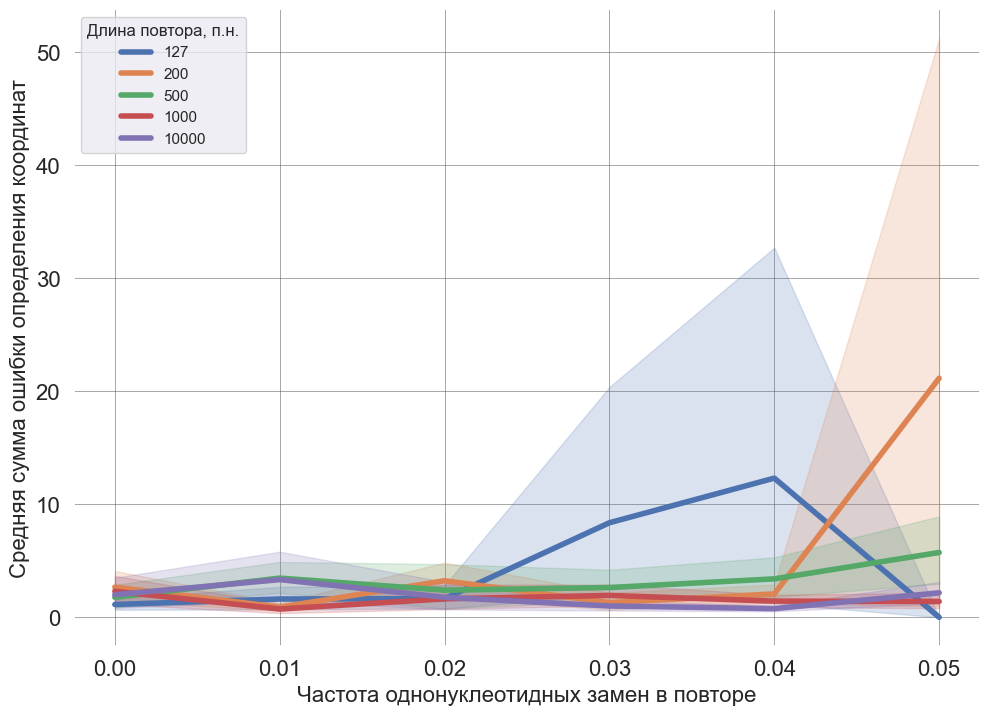

In [290]:
sns.set_theme(rc={'figure.figsize':(11.7,8.27)})

ax = sns.lineplot(
    all_coord_df,
    x='rate',
    y='coord_diff_sum',
    hue='repeat_len',
    linewidth=4.0,
    errorbar=('ci', 95)
)

ax.set_xlabel(f'Частота {x_label_part} в повторе', fontsize=16)
ax.set_ylabel('Средняя сумма ошибки определения координат', fontsize=16)

plt.legend(title='Длина повтора, п.н.')

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

ax.grid(True, color='#505050', linestyle='-', linewidth=0.5, alpha=0.7)
ax.set_facecolor('#ffffff')

plt.show(ax)

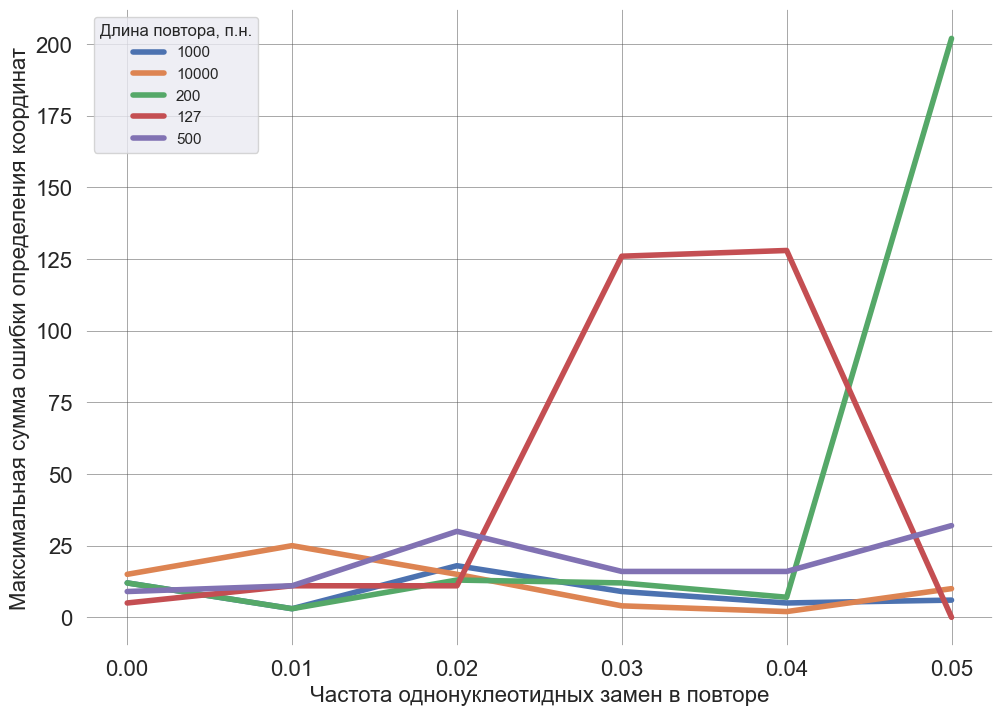

In [291]:
all_coord_max_df = all_coord_df.group_by(['rate', 'repeat_len']) \
    .agg(pl.col('coord_diff_sum').max().alias('max_coord_diff_sum'))

sns.set_theme(rc={'figure.figsize':(11.7,8.27)})

ax = sns.lineplot(
    all_coord_max_df,
    x='rate',
    y='max_coord_diff_sum',
    hue='repeat_len',
    linewidth=4.0
)

ax.set_xlabel(f'Частота {x_label_part} в повторе', fontsize=16)
ax.set_ylabel('Максимальная сумма ошибки определения координат', fontsize=16)

plt.legend(title='Длина повтора, п.н.')

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

ax.grid(True, color='#505050', linestyle='-', linewidth=0.5, alpha=0.7)
ax.set_facecolor('#ffffff')

plt.show(ax)